<a href="https://colab.research.google.com/github/annabarsukovaca-stack/Machine-Learning-Practice/blob/main/Ch4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

create 100 random numbers between 0 and 1, then values between 0 and 2. Gaussian noise is to make the data more realistic.

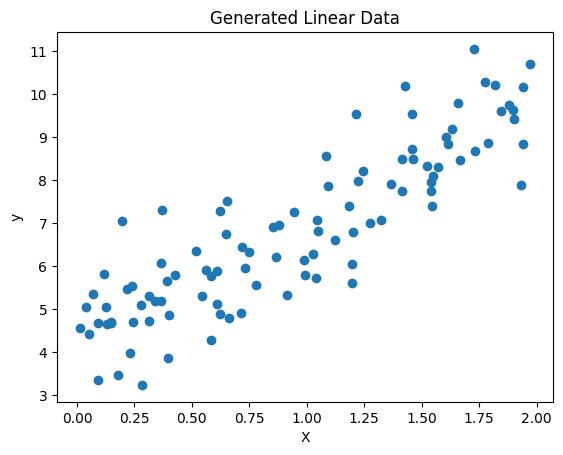

In [5]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Linear Data")
plt.show()

In [6]:
X_b = np.c_[np.ones((100, 1)), X]

The 1 allows the matrix calculation to include the intercept θo

In [7]:
theta_best = np.linalg.inv(
    X_b.T.dot(X_b)
).dot(X_b.T).dot(y)

print(theta_best)

[[4.21509616]
 [2.77011339]]


to calculate the parameters and minimize the MSE (Mean Standard Error)

In [8]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[
    np.ones((2, 1)),
    X_new
]

y_predict = X_new_b.dot(theta_best)

print(y_predict)

[[4.21509616]
 [9.75532293]]


explains what the model predicts when x = 0 and x = 2

<function matplotlib.pyplot.show(close=None, block=None)>

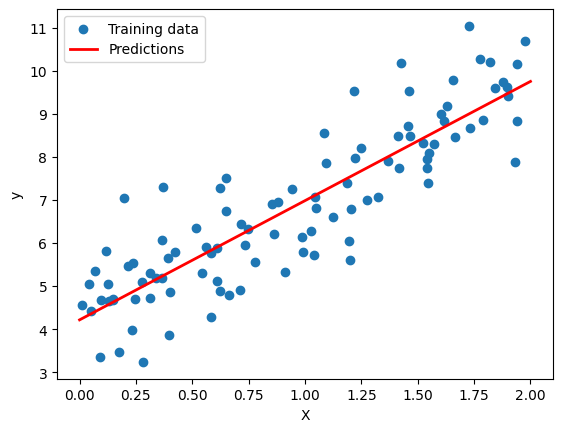

In [9]:
plt.scatter(X, y, label="Training data")

plt.plot(
    X_new,
    y_predict,
    "r-",
    linewidth=2,
    label="Predictions"
)

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show

In [10]:
lin_reg = LinearRegression()

lin_reg.fit(X, y)

LinearRegression()

In [11]:
print("Intercept:", lin_reg.intercept_)
print("Coefficient:", lin_reg.coef_)

Intercept: [4.21509616]
Coefficient: [[2.77011339]]


In [12]:
print(lin_reg.predict(X_new))

[[4.21509616]
 [9.75532293]]


In [13]:
#Batch Gradient Descent: starts with random parameters and gradually improves them
eta = 0.1
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1)

eta is the learning rate, so it controls how large each step is

In [14]:
#running the actual Gradient Descent
for iteration in range(n_iterations):

    gradients = (
        2 / m
        * X_b.T.dot(X_b.dot(theta) - y)
    )

    theta = theta - eta * gradients

In [15]:
print(theta)

[[4.21509616]
 [2.77011339]]


X_b.dot(theta) calculates the current predictions and X_b.dot(theta) - y calculates the errors and gradients = ... calculates the direction in which the error increases

theta = theta - eta * gradients moves thhe opposite direction to reduce the error

In [17]:
#tracking the error
theta = np.random.randn(2, 1)

cost_history = []

for iteration in range(n_iterations):

    predictions = X_b.dot(theta)

    cost = np.mean((predictions - y) ** 2)

    cost_history.append(cost)

    gradients = (
        2 / m
        * X_b.T.dot(predictions - y)
    )

    theta = theta - eta * gradients

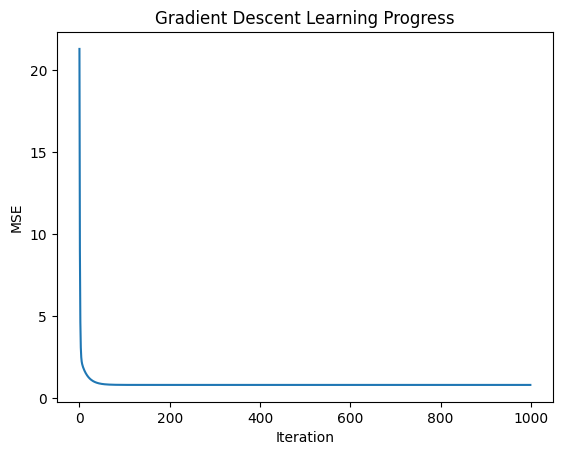

In [18]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Learning Progress")

plt.show()

In [23]:
#reusable function for different learning rates
def run_gradient_descent(eta, n_iterations=50):

    theta = np.random.randn(2, 1)

    cost_history = []

    for iteration in range(n_iterations):

        predictions = X_b.dot(theta)

        cost = np.mean(
            (predictions - y) ** 2
        )

        cost_history.append(cost)

        gradients = (
            2 / m
            * X_b.T.dot(predictions - y)
        )

        theta = theta - eta * gradients

    return cost_history

In [25]:
#trying 3 learning rates:
small_lr = run_gradient_descent(0.01)
good_lr = run_gradient_descent(0.1)
large_lr = run_gradient_descent(0.5)

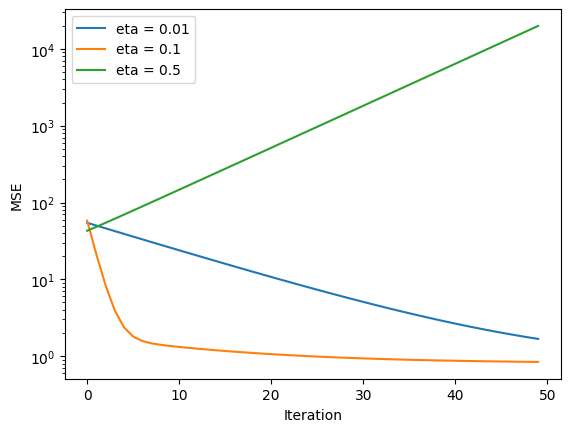

In [26]:
#plotting them:
plt.plot(small_lr, label="eta = 0.01")
plt.plot(good_lr, label="eta = 0.1")
plt.plot(large_lr, label="eta = 0.5")

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()

plt.show()

if learning rate is too small - learning is very slow, good rate - reaches the min efficiently, learning rate too large - may diverge

In [ ]:
#Stochatic Gradient Descent (Batch Descent uses all 100 training examples every time, but Stochatic Gradient uses only one random training instance per step)

In [28]:
n_epochs = 50
t0, t1 = 5, 50


def learning_schedule(t):

    return t0 / (t + t1)


theta = np.random.randn(2, 1)

In [31]:
for epoch in range(n_epochs):

    for i in range(m):

        random_index = np.random.randint(m)

        xi = X_b[
            random_index : random_index + 1
        ]

        yi = y[
            random_index : random_index + 1
        ]

        gradients = (
            2
            * xi.T.dot(
                xi.dot(theta) - yi
            )
        )

        eta = learning_schedule(
            epoch * m + i
        )

        theta = theta - eta * gradients

    print(theta)

[[4.19713484]
 [2.50395045]]
[[4.20454983]
 [2.72198559]]
[[4.08185165]
 [2.90630627]]
[[4.05320585]
 [2.93355279]]
[[4.13042262]
 [2.99917092]]
[[4.07943062]
 [2.97044187]]
[[4.15932786]
 [2.93415444]]
[[4.13055028]
 [2.86880601]]
[[4.13225372]
 [2.84907639]]
[[4.14589066]
 [2.81979916]]
[[4.20871144]
 [2.93210316]]
[[4.11460869]
 [2.797728  ]]
[[4.17684   ]
 [2.82033909]]
[[4.20358773]
 [2.79037246]]
[[4.20003912]
 [2.7867813 ]]
[[4.17337218]
 [2.75705739]]
[[4.21251705]
 [2.77608229]]
[[4.16822142]
 [2.74778668]]
[[4.16307075]
 [2.76945514]]
[[4.18861911]
 [2.75791623]]
[[4.21671864]
 [2.78301382]]
[[4.20115884]
 [2.77636492]]
[[4.20434911]
 [2.78709853]]
[[4.20163133]
 [2.78550928]]
[[4.15664001]
 [2.73437866]]
[[4.166594  ]
 [2.74258705]]
[[4.20206701]
 [2.76881931]]
[[4.17726776]
 [2.72713416]]
[[4.1892374 ]
 [2.74650405]]
[[4.19730058]
 [2.77372649]]
[[4.17237869]
 [2.75157967]]
[[4.16994922]
 [2.75661984]]
[[4.16937052]
 [2.76933334]]
[[4.18504555]
 [2.77722759]]
[[4.18644953]


In [32]:
sgd_reg = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty=None,
    eta0=0.1,
    random_state=42
)

sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None, random_state=42)

In [33]:
print("Intercept:", sgd_reg.intercept_)
print("Coefficient:", sgd_reg.coef_)

Intercept: [4.24365286]
Coefficient: [2.8250878]


In [34]:
#Mini-batch Gradient Descent
theta = np.random.randn(2, 1)

n_epochs = 50
batch_size = 20
eta = 0.1

In [40]:
for epoch in range(n_epochs):

    shuffled_indices = np.random.permutation(m)

    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    for i in range(0, m, batch_size):

        xi = X_b_shuffled[
            i : i + batch_size
        ]

        yi = y_shuffled[
            i : i + batch_size
        ]

        gradients = (
            2 / len(xi)
            * xi.T.dot(
                xi.dot(theta) - yi
            )
        )

        theta = theta - eta * gradients

In [41]:
print(theta)

[[4.17619696]
 [2.71876933]]


In [42]:
#Polynomial Regression (not linear)
np.random.seed(42)

m = 100

X_poly_data = (
    6
    * np.random.rand(m, 1)
    - 3
)

y_poly = (
    0.5
    * X_poly_data ** 2
    + X_poly_data
    + 2
    + np.random.randn(m, 1)
)

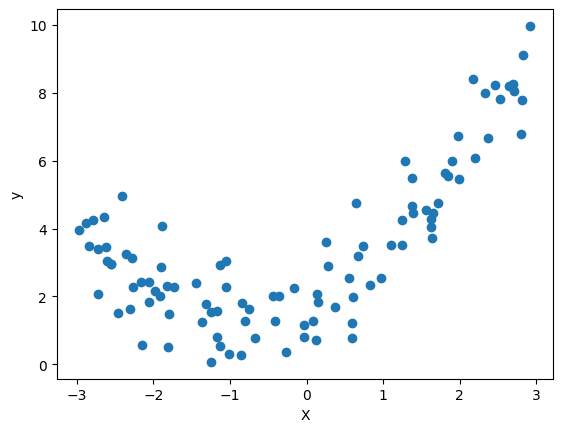

In [43]:
#visuals
plt.scatter(X_poly_data, y_poly)

plt.xlabel("X")
plt.ylabel("y")

plt.show()

In [45]:
#polynomial features
poly_features = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly_features.fit_transform(
    X_poly_data
)
print(X_poly[:5])

[[-0.75275929  0.56664654]
 [ 2.70428584  7.3131619 ]
 [ 1.39196365  1.93756281]
 [ 0.59195091  0.35040587]
 [-2.06388816  4.25963433]]


In [46]:
lin_reg = LinearRegression()

lin_reg.fit(X_poly, y_poly)

LinearRegression()

In [47]:
print(lin_reg.intercept_)

print(lin_reg.coef_)

[1.78134581]
[[0.93366893 0.56456263]]


In [48]:
#Plotting Polynomial Regression
X_new = np.linspace(
    -3,
    3,
    100
).reshape(100, 1)

X_new_poly = poly_features.transform(
    X_new
)

y_new = lin_reg.predict(
    X_new_poly
)

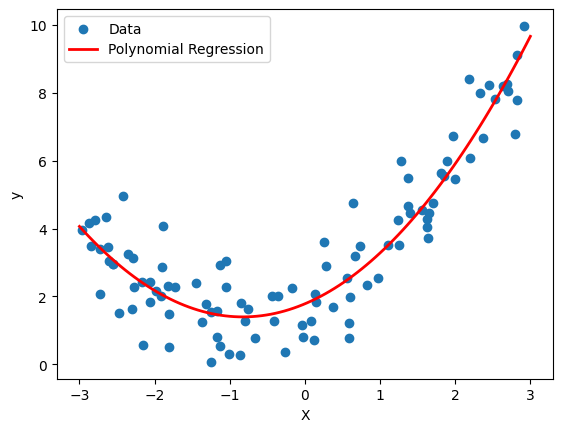

In [49]:
plt.scatter(
    X_poly_data,
    y_poly,
    label="Data"
)

plt.plot(
    X_new,
    y_new,
    "r-",
    linewidth=2,
    label="Polynomial Regression"
)

plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [50]:
polynomial_regression = Pipeline([

    (
        "poly_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),

    (
        "lin_reg",
        LinearRegression()
    )
])

In [51]:
polynomial_regression.fit(
    X_poly_data,
    y_poly
)

Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('lin_reg', LinearRegression())])

In [52]:
y_new = polynomial_regression.predict(
    X_new
)

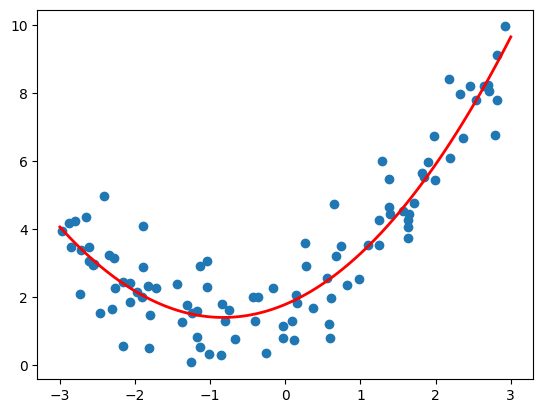

In [53]:
plt.scatter(
    X_poly_data,
    y_poly
)

plt.plot(
    X_new,
    y_new,
    "r-",
    linewidth=2
)

plt.show()

In [54]:
#training versus validation error
X_train, X_val, y_train, y_val = train_test_split(
    X_poly_data,
    y_poly,
    test_size=0.2,
    random_state=42
)

In [55]:
def plot_learning_curves(model, X, y):

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    train_errors = []
    val_errors = []

    for m in range(1, len(X_train)):

        model.fit(
            X_train[:m],
            y_train[:m]
        )

        y_train_predict = model.predict(
            X_train[:m]
        )

        y_val_predict = model.predict(
            X_val
        )

        train_errors.append(
            mean_squared_error(
                y_train[:m],
                y_train_predict
            )
        )

        val_errors.append(
            mean_squared_error(
                y_val,
                y_val_predict
            )
        )

    plt.plot(
        np.sqrt(train_errors),
        label="Training error"
    )

    plt.plot(
        np.sqrt(val_errors),
        label="Validation error"
    )

    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.legend()

    plt.show()

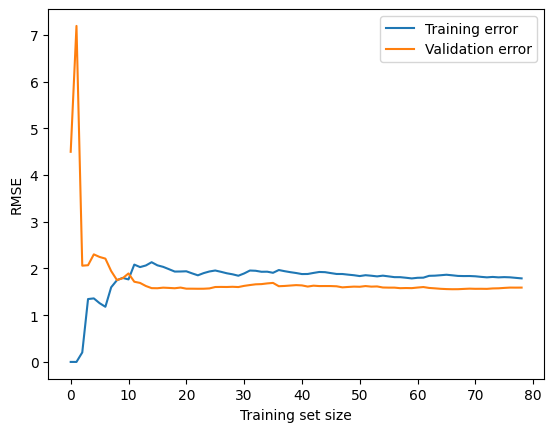

In [56]:
lin_reg = LinearRegression()

plot_learning_curves(
    lin_reg,
    X_poly_data,
    y_poly
)

if training error is high and validation error is also high - underfitting

In [57]:
#learning curves for a high-degree ploynomial
polynomial_regression = Pipeline([

    (
        "poly_features",
        PolynomialFeatures(
            degree=10,
            include_bias=False
        )
    ),

    (
        "lin_reg",
        LinearRegression()
    )
])

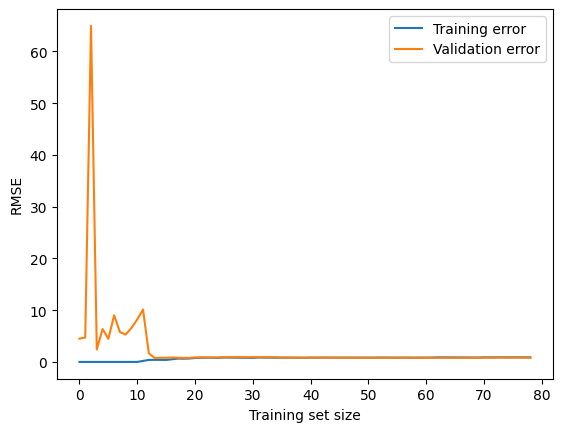

In [58]:
plot_learning_curves(
    polynomial_regression,
    X_poly_data,
    y_poly
)

if the mosel performs much better on training data then validation data - overfitting . The model learned the training data too closely and may not generalize well

In [ ]:
#ridge Regression

In [61]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(
    alpha=1,
    solver="cholesky"
)
ridge_reg.fit(
    X_poly_data,
    y_poly
)

Ridge(alpha=1, solver='cholesky')

In [62]:
ridge_reg.predict(
    [[1.5]]
)

array([4.82497007])

alpha controls how strong the regularization is (small alpha - weaker, large - stronger). Regularization helps prevent the model from becoming unnecessarily complex.

In [63]:
#Lasso Regression
from sklearn.linear_model import Lasso
lasso_reg = Lasso(
    alpha=0.1
)
lasso_reg.fit(
    X_poly_data,
    y_poly
)

Lasso(alpha=0.1)

In [64]:
lasso_reg.predict(
    [[1.5]]
)

array([4.77621741])

lasso can can push some feature coefficients all the way to zero.
This can effectively remove less useful features.

In [65]:
#elastic net (combines both Ridge and Lasso regularization)
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

elastic_net.fit(
    X_poly_data,
    y_poly
)

ElasticNet(alpha=0.1)

In [66]:
elastic_net.predict(
    [[1.5]]
)

array([4.78114505])

In [67]:
#Logistic Regression (from predictions to classification)
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

iris = datasets.load_iris()

X = iris["data"][:, 3:]

y = (
    iris["target"] == 2
).astype(int)

In [69]:
#predicting probabilities
X_new = np.linspace(
    0,
    3,
    1000
).reshape(-1, 1)